The most common type of big data in terms of size is data larger than is memory. Sometimes you may use a special system to do such analytics (e.g., Databricks or Spark), but the basics can be done easily in Python.

In this demo we show how to run a basic linear prediction model on data that is not all loaded into memory at once.

Notes:
1. You want to follow best practices for general computational efficiency.
2. In practice you will have to tune the system depending on your system and workflow.

In [ ]:
# pin dask_ml version. That needs an older version of dask: https://github.com/dask/dask-ml/issues/1012 and https://github.com/dask/dask-ml/issues/1016
!pip install dask==2025.1.0 dask_ml==2025.1.0

INFO: pip is looking at multiple versions of distributed to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of distributed to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: 

In [ ]:
import random
import numpy as np
random.seed(2718281)
np.random.seed(2718281)

In [1]:
import dask
import dask.array as da
from dask_ml.datasets import make_regression
from dask_ml.model_selection import train_test_split

n, d = 100000, 10
n_chunks = 10

#TODO: is this seed set?
X, y, coef = make_regression(n_samples=n, n_features=d,
                           chunks=n // n_chunks, noise=50, bias=0, coef=True, random_state=0)
display(X)

from dask_ml.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)
display(X_train)

dask.array<normal, shape=(100000, 10), dtype=float64, chunksize=(10000, 10), chunktype=numpy.ndarray>

dask.array<concatenate, shape=(90000, 10), dtype=float64, chunksize=(9000, 10), chunktype=numpy.ndarray>

In [2]:
# If can fit in memory, this will speed things up.
persist_for_demo = True
if persist_for_demo:
  X, y = dask.persist(X, y)
  X_train, X_test, y_train, y_test = dask.persist(X_train, X_test, y_train, y_test)

## OLS

In [3]:
# Using sklearn
from sklearn.linear_model import LinearRegression as sk_LinearRegression
ols_model = sk_LinearRegression(fit_intercept=True)
ols_model.fit(X_train, y_train)

print("sklearn: Intercept:", ols_model.intercept_, "Coefficients:", ols_model.coef_,"R2:", ols_model.score(X_train,y_train))

sklearn: Intercept: 0.10872052802234572 Coefficients: [19.80382328 91.13034772 38.61733215 19.42338259 22.24285941 78.95685883
 22.75148343 14.59012718 86.18023659  8.77221771] R2: 0.9104981870299322


In [4]:
# Using Dask
from dask_ml.linear_model import LinearRegression as dask_LinearRegression

dask_ols_model = dask_LinearRegression(solver='lbfgs', solver_kwargs={"lamduh":0}, random_state=0, fit_intercept=True) #lbfgs gives very close results. The dask-glm sets lamduh=1/C, so leave C and explicitly set lambduh using solver_kwargs (overrides other) to 0. You can do this for admm, lbfgs, or proximal_grad solvers (gradient_descent and newton solvers don't use regularization)
dask_ols_model.fit(X_train, y_train) #needs these be dask arrays

print("Dask: Intercept:", dask_ols_model.intercept_, "Coefficients:", dask_ols_model.coef_, "R2:", dask_ols_model.score(X_train,y_train))

c:\Users\bquis\anaconda3\envs\Colab\Lib\site-packages\dask\config.py:787: FutureWarning: Dask configuration key 'fuse_ave_width' has been deprecated; please use 'optimization.fuse.ave-width' instead
  warnings.warn(


Dask: Intercept: 0.10872052890299944 Coefficients: [19.80382274 91.13034683 38.6173318  19.42338321 22.24286027 78.95685905
 22.75148405 14.59012695 86.18023712  8.77221793] R2: 0.9104981870299321


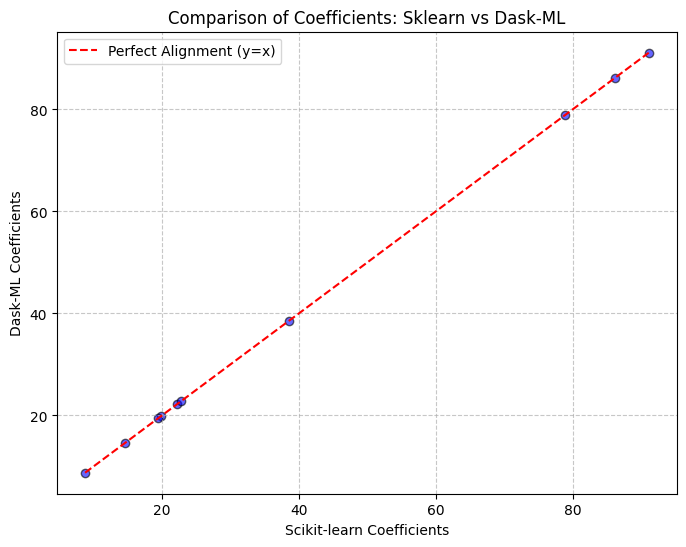

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients
sk_coefs = ols_model.coef_
dask_coefs = dask_ols_model.coef_

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(sk_coefs, dask_coefs, alpha=0.6, color='blue', edgecolors='k')

# Add a 45-degree line for reference (y=x)
max_val = max(sk_coefs.max(), dask_coefs.max())
min_val = min(sk_coefs.min(), dask_coefs.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Alignment (y=x)')

plt.xlabel('Scikit-learn Coefficients')
plt.ylabel('Dask-ML Coefficients')
plt.title('Comparison of Coefficients: Sklearn vs Dask-ML')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Penalized Linear Model
Cross validation over hyperparameters for ML model

In [ ]:
ridge_alphas = (0.1, 1.0, 10.0)

from sklearn.linear_model import RidgeCV as sk_RidgeCV
sk_ridgecv = sk_RidgeCV(fit_intercept=True, alphas=ridge_alphas, scoring='r2')
sk_ridgecv.fit(X_train, y_train)

print("sk_ridgecv:", "alpha star:", sk_ridgecv.alpha_, "Intercept:", sk_ridgecv.intercept_, "Coefficients:", sk_ridgecv.coef_, "R2:", sk_ridgecv.score(X_train,y_train))

sk_ridgecv: alpha star: 1.0 Intercept: 0.10871550130938012 Coefficients: [19.80360898 91.12932601 38.61690153 19.42316496 22.24260715 78.95598857
 22.75122602 14.589978   86.17927327  8.77211209] R2: 0.9104981869168608


If we split the data and do the hyperparameter search ourselves we could use `dask-ml`'s `LinearRegression`. It's easier, however, to have `dask-ml` manage the data and the search. This will require though that we use a model that can be repeatedly "partially" fit with small chunks of data at a time. Many of `sklearn`'s model already provide `partial_fit()`, and so `dask-ml` provides a generic wrapper functions (either `Incremental` if we just want the model itself, or `IncrementalSearchCV` if we're doing CV). Note that these ways of estimating the models won't be as accurate as full-sample estimations using the standard `sklearn`'s models' `fit()`. Also, in some cases you may want to call `partial_fit()` multiple times.

To do `IncrementalSearchCV`, we need to setup a dask cluster. We'll start one up with just a single worker here, but you may want to parallelize on your own machine (look at how many cores you can feasibly use).

In [24]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 16,Total memory: 15.68 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:49294,Workers: 1
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 15.68 GiB
Comm: tcp://127.0.0.1:49302,Total threads: 16
Dashboard: http://127.0.0.1:49303/status,Memory: 15.68 GiB
Nanny: tcp://127.0.0.1:49297,


In [ ]:
# Do Ridge with CV penalty
from dask_ml.model_selection import IncrementalSearchCV
sklearn_ridge = SGDRegressor(penalty='l2', fit_intercept=True, random_state=0, learning_rate='invscaling') #data already centered
params = {'alpha': ridge_alphas}
dask_ridgecv_search = IncrementalSearchCV(sklearn_ridge, params, n_initial_parameters="grid", random_state=0, scoring='r2', tol=0.001, max_iter=100)
dask_ridgecv_search.fit(X_train, y_train)
dask_ridgecv = dask_ridgecv_search.best_estimator_

print("dask_ridgecv:", "alpha star:", dask_ridgecv_search.best_params_['alpha'], "Intercept:", dask_ridgecv.intercept_[0], "Coefficients:", dask_ridgecv.coef_, "R2:", dask_ridgecv.score(X_train,y_train))

dask_ridgecv: alpha star: 0.1 Intercept: -0.15531292709507916 Coefficients: [17.85534331 82.87773523 34.46182698 17.51551576 20.08461543 72.61793253
 21.25158793 13.52697298 78.92491386  7.51533511] R2: 0.9035391111145588


Note: For `SGDRegressor` we need to make sure the features are standardized. Ours is already in this example. If you need to do it, you can either do it initially, or you can do do them in `sklearn` pipeline:

``` python
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
sgd_pipe = make_pipeline(
    StandardScaler(),
    SGDRegressor(...)
)
sgd_pipe.fit(X, y)
model = sgd_pipe.named_steps['sgdregressor'] # Extract the regressor from the pipeline to see coefficients
```

### Neural Network

We also show that a simple feed-forward neural network with no hidden layer is just a linear regression. For this, we can use `sklearn`'s Multi-Layer Perceptron (MLP) Regressor. This model impliments `partial_fit` so can also be used with `dask-ml`'s incremental tools.

In [27]:
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(hidden_layer_sizes = [], alpha=0, solver='lbfgs', random_state=0) #activation='identity', 
nn.fit(X_train, y_train)
nn_coefs = [c[0] for c in nn.coefs_[0]]
print("MLP:", "Intercept:", nn.intercepts_[0][0], "Coefficients:", nn_coefs,"R2:", nn.score(X,y))

MLP: Intercept: 0.10871998897342393 Coefficients: [19.803823996428637, 91.13034575465849, 38.61733050105903, 19.423381734036486, 22.242858868832343, 78.95686191512853, 22.751484172028597, 14.590127505002114, 86.18023667188449, 8.772215062355519] R2: 0.9109153930519287


## Specialized versions of tree algorithms
Specialized algorithms exist for `xgboost` and `lightgbm`

In [25]:
import xgboost as xgb
from xgboost import dask as dxgb

clf = dxgb.DaskXGBRegressor(n_estimators=100, tree_method="hist", seed=0) #hist is newer and faster
clf.client = client  # assign the client
clf.fit(X_train, y_train, eval_set=[(X_train, y_train)])
#clf.predict(X_test)

DaskXGBRegressor(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bynode=None,
                 colsample_bytree=None, device=None, early_stopping_rounds=None,
                 enable_categorical=False, eval_metric=None, feature_types=None,
                 feature_weights=None, gamma=None, grow_policy=None,
                 importance_type=None, interaction_constraints=None,
                 learning_rate=None, max_bin=None, max_cat_threshold=None,
                 max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                 max_leaves=None, min_child_weight=None, missing=nan,
                 monotone_constraints=None, multi_strategy=None,
                 n_estimators=100, n_jobs=None, num_parallel_tree=None, ...)

References:
- https://examples.dask.org/machine-learning/incremental.html
- https://ml.dask.org/incremental.html

In [26]:
client.shutdown()

In [ ]:
# Reproducibility info
import sys
print(f'Python:       {sys.version}')
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'Matplotlib:   {matplotlib.__version__}')
print(f'dask: {dask.__version__}')
print(f'dask-ml: {dask_ml.__version__}')